# Multi-Agent Debate for Quantitative Trading Signal Discovery

*Patrick Flanagan · CS153 Final Project · Stanford*

## Project Goal

Build an LLM agent system that helps my systematic quantitative-equity strategy find new candidate factor ideas.

# Q1: Why did you build what you did?

*What bottlenecks did you identify? What inspired you to develop this project?*

The next three subsections explain the trading strategy I run, what "factors" are, and why finding good ones is the creative bottleneck the LLM is here to fix.

## What kind of trading is this

I run a **systematic quantitative-equity strategy**. Every trading day, a computer system I built ranks the universe of ~3,000 US large-cap stocks, buys the top of the list (long), and simultaneously sells short the bottom (short). It holds for a few days, re-ranks the universe, and repeats. Because the long and short sides are equal-sized, the strategy is roughly **market-neutral** — my portfolio's beta to the S&P 500 is **-0.058**, effectively zero. The bet is that the spread between top-ranked and bottom-ranked stocks stays positive after costs, in any kind of market.

## What factors are

The daily ranking is built from **factors** — formulas that produce a number for each stock each day. Classic example: 12-month price momentum. The hypothesis is that ranking stocks by their return over the previous 12 months will predicts which stocks will outperform over the next window. My strategy uses **several thousand factors**. A daily-updating machine learning model takes all of their values for every stock and combines them into one final composite score that drives the long/short ranking. **The strategy's quality is bottlenecked on the quality of the factor library.**

## Why this is hard, and where the LLM fits

The metric I care about is **Sharpe ratio** — annualised return divided by annualised volatility. A Sharpe of 1 is fine, 2 is rare, and 3 is the kind of thing institutional investors pay attention to. My deployed configuration runs at **Sharpe 3.33** over 4.8 years out of sample. Getting there is hard because *most apparent factors are noise* — they look great on historical data they were fit on and fail on data they weren't. To keep finding edges before existing ones decay, the strategy needs a constant stream of new factor ideas to test. **Generating those is the creative bottleneck.** This project is an LLM agent system that generates them, with the failure modes of single-LLM ideation explicitly designed out.

# Q2: How exactly does the product work?

*Track: **[3] Automation/Agent Systems** — agent training, data, etc.*

Four specialised LLM agents, run in a structured pipeline. The cells below show the actual production prompts, walk through three real recorded debates, and exhibit the aggregate operational metrics from two months of runtime.

## The agents, in code

Four agent roles, each with its own system prompt. The cell below imports the actual production prompts from [`agents.py`](agents.py) and prints them.

In [1]:
from agents import PROPOSER_SLOTS, PROPOSER_SYSTEM, CRITIC_SYSTEM, REVISOR_SYSTEM, RANKER_SYSTEM

print('=== PROPOSER system prompt (shared by all 5 parallel slots) ===\n')
print(PROPOSER_SYSTEM)
print()
print('=== Slot mandates that make the 5 Proposers diverse ===\n')
for slot in [PROPOSER_SLOTS[0], PROPOSER_SLOTS[2], PROPOSER_SLOTS[4]]:
    print(f"--- Slot: {slot['slot']}  (n={slot['n']}) ---")
    print(slot['instruction'])
    print()
print('=== CRITIC system prompt (adversarial review) ===\n')
print(CRITIC_SYSTEM)

=== PROPOSER system prompt (shared by all 5 parallel slots) ===

You are a quantitative researcher proposing new data series for a systematic trading system. Return ONLY valid JSON arrays. Be creative but precise — every proposed input must be computable from observable market or fundamental data, with no lookahead.

=== Slot mandates that make the 5 Proposers diverse ===

--- Slot: textbook  (n=5) ---
Generate 5 input proposals using well-established quantitative signals. Academic factor literature — Fama-French extensions, quality metrics, momentum variants, volatility risk premia. Adapt known signals to this specific failure.

--- Slot: contrarian  (n=5) ---
Generate 5 input proposals based on contrarian or mean-reversion logic. Things most quants would NOT build. Signals that go AGAINST the current factor drivers. If the existing signal over-indexes on earnings growth, propose inputs that capture when earnings growth is misleading.

--- Slot: orthogonal  (n=5) ---
Generate 5 input 

## All five Proposer mandates side-by-side

For context, here are all five slot mandates. The instruction *"you are one of 5 — do not hedge, commit to your mandate"* is the entire reason candidate sets are diverse instead of all-momentum.

In [2]:
import json
from pathlib import Path
from textwrap import indent

with open('prompts/proposer_slot_instructions.json') as f:
    slots = json.load(f)

for s in slots['main_slots']:
    print(f"── {s['slot']}  (n={s['n']}) ──")
    print(indent(s['instruction'], '   '))
    print()

── textbook  (n=5) ──
   Generate 5 input proposals using well-established quantitative signals. Academic factor literature — Fama-French extensions, quality metrics, momentum variants, volatility risk premia. Adapt known signals to this specific failure.

── cross_domain  (n=5) ──
   Generate 5 input proposals that combine data from at least 2 DIFFERENT domains. Examples: fundamental × technical (earnings yield relative to momentum), macro × price (vol regime adjusted returns), volume × fundamental (turnover-scaled quality). The alpha must come from the COMBINATION, not either input alone.

── contrarian  (n=5) ──
   Generate 5 input proposals based on contrarian or mean-reversion logic. Things most quants would NOT build. Signals that go AGAINST the current factor drivers. If the existing signal over-indexes on earnings growth, propose inputs that capture when earnings growth is misleading.

── interaction  (n=5) ──
   Generate 5 input proposals that capture INTERACTIONS between vari

## A representative debate — the common case

Most days, the Critic approves most candidates, sends a few back for revision, rejects almost none. The Revisor recovers ~4 more, and the slate is ready without backfill or the Ranker.

In [3]:
debate1 = json.loads(Path('transcripts/debate_001_revision_heavy.json').read_text())

print('Scenario:', debate1['scenario'])
print()
print('Challenge:')
print(indent(debate1['challenge'], '  '))
print()
print(f"Raw proposals: {debate1['n_raw']}")
print(f"Critic verdicts: approve={debate1['n_approved']}  revise={debate1['n_revise']}  reject={debate1['n_reject']}")
print(f"After revision: +{debate1['n_revised_then_approved']} approved")
print(f"After backfill: {debate1['n_after_backfill']} total approved")
print(f"LLM calls: {debate1['llm_calls']}   wall clock: {debate1['elapsed_s']}s")

Scenario: Common case for the debate system: ~80% of proposals need revision but very few are outright rejected — the Critic finds issues but they're all addressable.

Challenge:
  The machine-learning equity ranker underperformed on a specific historical date (alpha ≈ -2.9% vs. expected). Inspection shows over-rotation into a crowded earnings-growth × momentum trade just before a sharp volatility-regime shift. Propose new candidate research signals that, added to the candidate factor library, would have given the model more diverse ranking information on this kind of day. No lookahead; computable from observable market/fundamentals data.

Raw proposals: 29
Critic verdicts: approve=10  revise=10  reject=0
After revision: +4 approved
After backfill: 14 total approved
LLM calls: 13   wall clock: 495s


### Sample proposals — one per slot

Note the variety. *Textbook* leans on well-known factor literature; *cross_domain* mixes data types; *contrarian* deliberately inverts the prevailing model bias; *interaction* looks for ratios and conditionals; *orthogonal* targets uncorrelated drivers.

In [4]:
for p in debate1['sample_proposals_by_slot']:
    print(f"── [{p['slot']}] {p['input_name']}  ({p['data_type']}) ──")
    print(f"   rationale:  {p['rationale']}")
    print(f"   derivation: {p['derivation']}")
    print()

── [textbook] proposal_001_rolling_return_skew  (price) ──
   rationale:  Extreme left-tail skewness in recent returns predicts periods when the strategy mis-ranks winners, allowing pre-emptive sector tilt.
   derivation: 63-day rolling skew of 5-day returns

── [cross_domain] proposal_007_cashflow_to_macro_liq  (fundamental) ──
   rationale:  When firms have strong cash-flow quality but the macro liquidity backdrop is poor, the ranker tends to mis-weight them. The ratio surfaces those regimes.
   derivation: ratio of fundamental_quality_score to a macro_liquidity_index

── [contrarian] proposal_012_cash_conversion_inverse  (fundamental) ──
   rationale:  Existing model over-weights cash-conversion efficiency vs. price-stretch, causing mis-priced high-distance picks; this ratio inverts that relationship to surface mean-reverting opportunities.
   derivation: ratio of cash_conversion_cycle to distance_from_52w_high

── [interaction] proposal_018_macro_liq_x_sector_breadth  (macro) ──
  

## The Critic doing its job

Three sample verdicts from this debate. The first is a textbook lookahead bias the Critic caught and provided a one-line fix for. The second is a robustness flaw (sensitivity to low-ADV days). The third is a dedup catch — the proposed factor is a rename of something already in the library.

In [5]:
for v in debate1['sample_critic_catches']:
    print(f"── verdict: {v['verdict'].upper()}  on  {v['input_name']} ──")
    print(f"   reasoning: {v['reasoning']}")
    if v.get('revision_guidance'):
        print(f"   guidance:  {v['revision_guidance']}")
    print()

── verdict: REVISE  on  proposal_003_60day_rolling_alpha ──
   reasoning: The proposed derivation uses a 60-day rolling regression on the full window including the target date. This embeds lookahead — the regression coefficient for day t would be fitted on data including day t's return.
   guidance:  Shift the rolling window to end at t-1, not t. Use the coefficient from the regression on days [t-60, t-1] to compute the alpha for day t.

── verdict: REVISE  on  proposal_014_volume_weighted_quality ──
   reasoning: Volume-weighted quality is sensitive to days with abnormally low ADV (e.g., holidays, halts). Without an ADV floor or winsorisation, single low-ADV days will dominate the cross-section.
   guidance:  Add a minimum ADV threshold (5th percentile across the universe on each date) or winsorise the volume weights at the 5/95 percentiles.

── verdict: REJECT  on  proposal_021_short_interest_zscore ──
   reasoning: Duplicate of an existing candidate factor — already captured in the 

## A heavier-reject debate — the Critic as filter

This is the case people imagine the Critic *should* handle: most textbook proposals double down on the failure direction, and the Critic rejects them outright. Two backfill slots run to fill out the slate.

In [6]:
debate2 = json.loads(Path('transcripts/debate_002_heavy_reject.json').read_text())

print('Scenario:', debate2['scenario'])
print()
print(f"Raw: {debate2['n_raw']}  approve: {debate2['n_approved']}  revise: {debate2['n_revise']}  REJECT: {debate2['n_reject']}")
print(f"Final slate after backfill: {debate2['n_after_backfill']}")
print(f"LLM calls: {debate2['llm_calls']}   wall clock: {debate2['elapsed_s']}s")
print()
print('── Sample rejections ──')
for v in debate2['sample_critic_catches']:
    if v['verdict'] == 'reject':
        print(f"  • {v['input_name']}")
        print(f"      \"{v['reasoning']}\"\n")

Scenario: Heavy-rejection case (7 of 17 rejected outright; only 6 approved). Triggers backfill round. Demonstrates the Critic acting as a real filter — the failure mode being researched was unusual and most textbook proposals didn't engage with it.

Raw: 17  approve: 6  revise: 4  REJECT: 7
Final slate after backfill: 15
LLM calls: 15   wall clock: 629s

── Sample rejections ──
  • proposal_004_simple_value_score
      "Proposes a plain book-to-market value score. This is one of the most heavily-loaded inputs already in the canonical library. No incremental information."

  • proposal_009_momentum_acceleration
      "On a vol-spike day momentum signals are precisely what the ranker over-weighted. Proposing a momentum acceleration variant doubles down on the failed direction. The mandate for this debate is to find inputs that re-rank, not reinforce."

  • proposal_011_realised_vol_60d
      "Realised volatility over 60 days is the lagging indicator the signal already had access to. The 

## The Ranker in action — clean-pass case

When the Critic approves more candidates than the slate cap (`max_approved = 15`), the Ranker fires. It picks for **diversity first**, **relevance second**, and tie-breaks on **derivation simplicity**.

In [7]:
debate3 = json.loads(Path('transcripts/debate_003_clean_pass.json').read_text())

print('Scenario:', debate3['scenario'])
print()
print(f"Approved: {debate3['n_approved']}  Ranker invoked: {debate3['ranker_invoked']}  selected: {debate3['ranker_selected']}")
print()
print('Ranker rationale:')
print(indent(debate3['ranker_selection_rationale'], '  '))

Scenario: Clean-pass case: 16 raw → 15 approved on the first Critic round, no rejections, only one revision. Triggers the Ranker because we exceed max_approved (15) and need to pick a diverse top-12. Demonstrates the Ranker's role.

Approved: 15  Ranker invoked: True  selected: 12

Ranker rationale:
  Critic approved 15 candidates but the slate is capped at 12. The Ranker's chain-of-thought (preserved in the JSON output) prioritised one input from each Proposer slot (5 inputs), then filled the remaining 7 slots with the highest-relevance inputs, preferring proposals whose derivations used the fewest base inputs (simplicity tie-breaker).


## Production operational metrics

Everything above is one debate at a time. The system has been running on a cron for ~2 months. The aggregate numbers live in `results/operational_metrics.json`.

In [8]:
ops = json.loads(Path('results/operational_metrics.json').read_text())

funnel = ops['llm_proposal_funnel']
print('── Proposal funnel ──')
print(f"  Raw LLM proposals:            {funnel['total_llm_proposals_recorded']:>6,}")
print(f"  Materialised (Critic-passed): {funnel['materialized_to_factor_library']:>6,}   ({funnel['materialization_rate']:.1%})")
print()
rt = ops['per_debate_runtime']
print('── Per-debate runtime (sample of 25 days) ──')
print(f"  Raw proposals/debate:  min={rt['raw_proposals_per_debate']['min']} med={rt['raw_proposals_per_debate']['median']} max={rt['raw_proposals_per_debate']['max']}")
print(f"  Approved/debate:       min={rt['approved_per_debate']['min']} med={rt['approved_per_debate']['median']} max={rt['approved_per_debate']['max']}")
print(f"  LLM calls/debate:      min={rt['llm_calls_per_debate']['min']} med={rt['llm_calls_per_debate']['median']} max={rt['llm_calls_per_debate']['max']}")
print(f"  Wall clock (s):        min={rt['wall_clock_seconds_per_debate']['min']} med={rt['wall_clock_seconds_per_debate']['median']} max={rt['wall_clock_seconds_per_debate']['max']}")

── Proposal funnel ──
  Raw LLM proposals:             1,214
  Materialised (Critic-passed):    448   (36.9%)

── Per-debate runtime (sample of 25 days) ──
  Raw proposals/debate:  min=16 med=27 max=35
  Approved/debate:       min=11 med=14 max=15
  LLM calls/debate:      min=8 med=13 max=16
  Wall clock (s):        min=270 med=535 max=1191


### Funnel chart

Two numbers, one story. **1,214** raw LLM proposals went in. The Critic plus a validation gate rejected roughly two thirds of them. **448** survived and entered the live factor library — about **37%**.

That 37% rate is the empirical fingerprint that the architecture is doing real work. A single-LLM self-review approves close to 100%. Rejecting two thirds is the adversarial Critic catching the lookahead bugs, duplicates, and proposals that double down on whatever direction just failed.

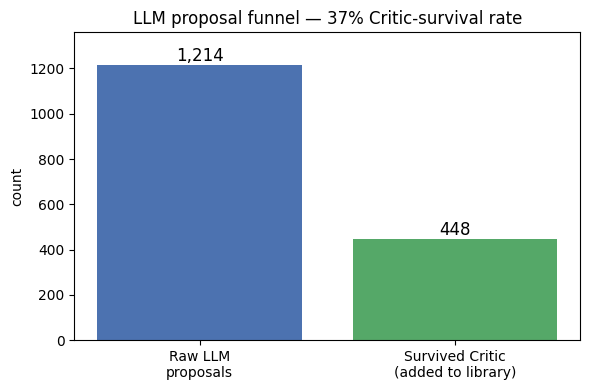

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
stages = ['Raw LLM\nproposals',
          'Survived Critic\n(added to library)']
counts = [funnel['total_llm_proposals_recorded'],
          funnel['materialized_to_factor_library']]
bars = ax.bar(stages, counts, color=['#4c72b0', '#55a868'])
for b, c in zip(bars, counts):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f'{c:,}',
            ha='center', va='bottom', fontsize=12)
ax.set_ylabel('count')
ax.set_title(f"LLM proposal funnel — {funnel['materialization_rate']:.0%} Critic-survival rate")
ax.set_ylim(0, max(counts) * 1.12)
plt.tight_layout()
plt.show()

# Q3: Potential use cases of the product?

*What is the impact and how is this valuable to society? How do you envision people using this tool?*

The next sections show the impact: where this architecture transfers beyond my trading strategy (other research-style workflows), where this LLM debate sits inside the live strategy that it actually feeds, and the strategy's real out-of-sample performance.

## Beyond quant trading

The architecture isn't quant-specific. The core pattern — mandate-diversified parallel Proposers, a structurally separated adversarial Critic, cheap batched revision, diversity-first ranking — applies anywhere you need to generate candidate ideas and filter them rigorously. A few examples where it would drop in:

- **Scientific hypothesis generation.** Five Proposers with different theoretical lenses generate research hypotheses; the Critic evaluates each for testability and prior-literature overlap.
- **Legal argument drafting.** Different mandates produce arguments from different doctrinal frameworks; the Critic checks precedent support and logical consistency.
- **Drug-discovery candidate screening.** Proposers with different chemical-space lenses propose candidates; the Critic checks for synthesizability, prior failure modes, and target-specificity.
- **Code review at scale.** Proposers suggest fixes from different angles (correctness, performance, security, style); the Critic evaluates each.

Single-LLM ideation has structural failure modes — narrow ideas, self-approval — that aren't fixed by prompt tweaks or higher temperature. The fix is architectural, and it transfers. Anyone whose workflow is *generate candidates → filter rigorously* could use the same four-agent design with their own mandates and their own Critic criteria.

## Where the LLM system sits in the trading strategy

The LLM-proposed candidate factors are the *upstream input* to the strategy — they are not the strategy itself. The factors feed several downstream stages of the production trading pipeline before any of it touches the live portfolio. The K × leverage performance table below reflects the integrated behaviour of the full pipeline.


### Production snapshot — Performance from 2021-07-16 → 2026-05-05 (4.8 years, 1,206 trading days)
Deployed configuration: **K=25 at 1.5× gross leverage**.

In [10]:
import pandas as pd

rows = [
    {'K':   5, 'CAGR (unlev)': 84.1, 'Sharpe (unlev)': 2.77, 'MaxDD (unlev)': -15.1,
     'CAGR (1.5x)': 142.7, 'Sharpe (1.5x)': 2.74, 'MaxDD (1.5x)': -25.2, 'Final mult (1.5x)': 69.6},
    {'K':  10, 'CAGR (unlev)': 87.6, 'Sharpe (unlev)': 3.16, 'MaxDD (unlev)': -12.5,
     'CAGR (1.5x)': 141.1, 'Sharpe (1.5x)': 3.02, 'MaxDD (1.5x)': -20.8, 'Final mult (1.5x)': 67.5},
    {'K':  25, 'CAGR (unlev)': 81.1, 'Sharpe (unlev)': 3.43, 'MaxDD (unlev)': -10.0,
     'CAGR (1.5x)': 134.0, 'Sharpe (1.5x)': 3.33, 'MaxDD (1.5x)': -15.7, 'Final mult (1.5x)': 58.4},
    {'K':  50, 'CAGR (unlev)': 70.9, 'Sharpe (unlev)': 3.45, 'MaxDD (unlev)':  -8.6,
     'CAGR (1.5x)': 119.9, 'Sharpe (1.5x)': 3.44, 'MaxDD (1.5x)': -12.9, 'Final mult (1.5x)': 43.4},
    {'K': 100, 'CAGR (unlev)': 58.8, 'Sharpe (unlev)': 3.44, 'MaxDD (unlev)':  -7.3,
     'CAGR (1.5x)':  98.6, 'Sharpe (1.5x)': 3.44, 'MaxDD (1.5x)': -10.8, 'Final mult (1.5x)': 26.6},
    {'K': 250, 'CAGR (unlev)': 42.2, 'Sharpe (unlev)': 3.32, 'MaxDD (unlev)':  -6.3,
     'CAGR (1.5x)':  70.4, 'Sharpe (1.5x)': 3.40, 'MaxDD (1.5x)':  -9.3, 'Final mult (1.5x)': 12.8},
]
df = pd.DataFrame(rows).set_index('K')
pd.options.display.float_format = '{:.2f}'.format
print(df.to_string())
print()
print('DEPLOYED ROW: K=25 @ 1.5× → CAGR 134.0%, Sharpe 3.33, MaxDD -15.7%')
print('Additional metrics on the deployed configuration:')
print('  NW t-stat:                  8.17')
print('  SPY beta:                  -0.058  (effectively market-neutral)')
print('  5-day non-overlap hit rate: 71.8%')
print('  Positive months / total:    48 / 59  (81%)')
print('  Best month / worst month:   +28.4% / -5.4%')
print('  Final portfolio value:      58.4× initial')

     CAGR (unlev)  Sharpe (unlev)  MaxDD (unlev)  CAGR (1.5x)  Sharpe (1.5x)  MaxDD (1.5x)  Final mult (1.5x)
K                                                                                                            
5           84.10            2.77         -15.10       142.70           2.74        -25.20              69.60
10          87.60            3.16         -12.50       141.10           3.02        -20.80              67.50
25          81.10            3.43         -10.00       134.00           3.33        -15.70              58.40
50          70.90            3.45          -8.60       119.90           3.44        -12.90              43.40
100         58.80            3.44          -7.30        98.60           3.44        -10.80              26.60
250         42.20            3.32          -6.30        70.40           3.40         -9.30              12.80

DEPLOYED ROW: K=25 @ 1.5× → CAGR 134.0%, Sharpe 3.33, MaxDD -15.7%
Additional metrics on the deployed configuration:
  

## The strategy's actual equity curve

Below is the daily cumulative equity curve for the deployed strategy (K=25 at 1.5× gross leverage), starting at \$1 on 2021-07-16 and running through 2026-05-05 — 1,206 trading days, ~4.8 years out-of-sample.

The top panel uses a log scale so the compounding is visible across the full range. The bottom panel shows the running drawdown — the percentage decline from the all-time-high equity value. These are the actual daily returns of the model running on the live factor library that the LLM debate has been feeding.

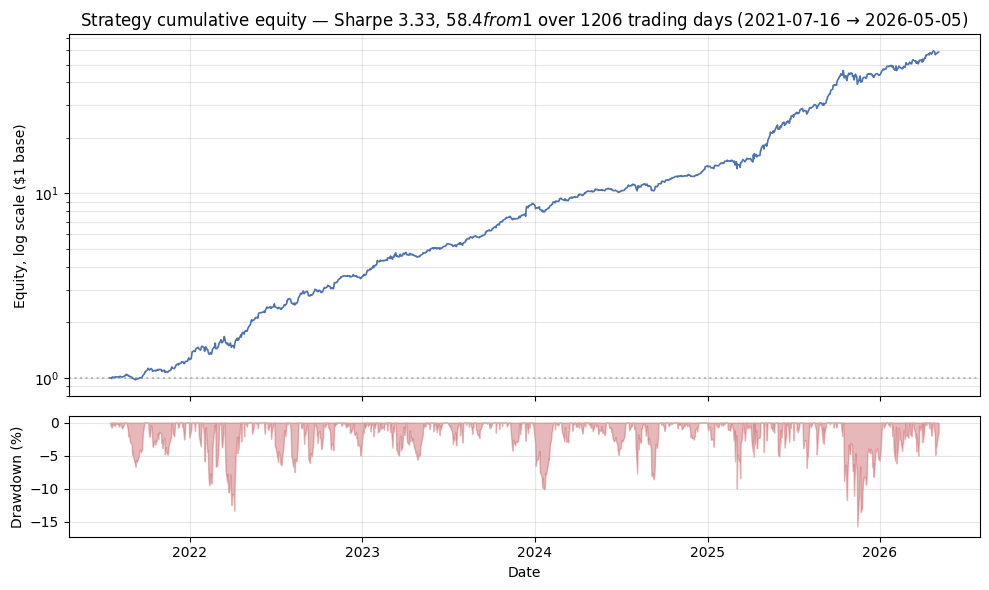

Final equity:    $58.44  (58.4× starting capital)
CAGR:            134.0%
Worst drawdown:  -15.7%
Sharpe ratio:    3.33


In [11]:
eq = json.loads(Path('results/strategy_returns.json').read_text())

df_eq = pd.DataFrame({
    'date': pd.to_datetime(eq['dates']),
    'equity': eq['cum_equity'],
}).set_index('date')
df_eq['drawdown_pct'] = (df_eq['equity'] / df_eq['equity'].cummax() - 1.0) * 100

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})

axes[0].plot(df_eq.index, df_eq['equity'], color='#4c72b0', linewidth=1.2)
axes[0].set_yscale('log')
axes[0].set_ylabel('Equity, log scale ($1 base)')
axes[0].set_title(f"Strategy cumulative equity — Sharpe {eq['sharpe']:.2f}, "
                  f"${df_eq['equity'].iloc[-1]:.1f} from $1 over "
                  f"{eq['window']['n_days']} trading days "
                  f"({eq['window']['start']} → {eq['window']['end']})")
axes[0].axhline(1.0, color='gray', linestyle=':', alpha=0.5)
axes[0].grid(alpha=0.3, which='both')

axes[1].fill_between(df_eq.index, df_eq['drawdown_pct'], 0, color='#c44e52', alpha=0.4)
axes[1].set_ylabel('Drawdown (%)')
axes[1].set_xlabel('Date')
axes[1].grid(alpha=0.3)
axes[1].set_ylim(min(df_eq['drawdown_pct'].min() * 1.1, -1), 1)

plt.tight_layout()
plt.show()

print(f"Final equity:    ${df_eq['equity'].iloc[-1]:.2f}  ({df_eq['equity'].iloc[-1]:.1f}× starting capital)")
print(f"CAGR:            {eq['cagr']*100:.1f}%")
print(f"Worst drawdown:  {df_eq['drawdown_pct'].min():.1f}%")
print(f"Sharpe ratio:    {eq['sharpe']:.2f}")

### Monthly returns

Aggregated from the same daily returns. Useful because it shows the result isn't living in one good year — **48 of the 59 OOS months were positive (81%)**, and even the worst month is only down ~5%.

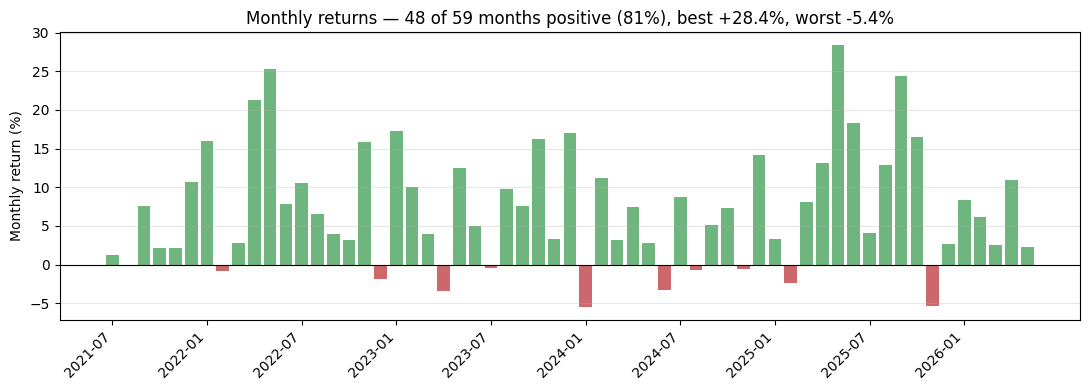

Months positive:    48 / 59  (81%)
Best month:         +28.4%
Worst month:         -5.4%
Average month:      +7.40%


In [12]:
daily = pd.DataFrame({
    'date': pd.to_datetime(eq['dates']),
    'ret':  eq['daily_returns'],
}).set_index('date')

monthly = (1 + daily['ret']).resample('ME').prod() - 1
months = monthly.index.strftime('%Y-%m')

fig, ax = plt.subplots(figsize=(11, 4))
colors = ['#55a868' if r > 0 else '#c44e52' for r in monthly]
ax.bar(range(len(monthly)), monthly * 100, color=colors, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(range(0, len(monthly), 6))
ax.set_xticklabels(months[::6], rotation=45, ha='right')
ax.set_ylabel('Monthly return (%)')
ax.set_title(f"Monthly returns — {(monthly > 0).sum()} of {len(monthly)} months positive "
             f"({(monthly > 0).mean() * 100:.0f}%), best +{monthly.max() * 100:.1f}%, worst {monthly.min() * 100:.1f}%")
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"Months positive:    {(monthly > 0).sum()} / {len(monthly)}  ({(monthly > 0).mean()*100:.0f}%)")
print(f"Best month:         +{monthly.max()*100:.1f}%")
print(f"Worst month:         {monthly.min()*100:.1f}%")
print(f"Average month:      +{monthly.mean()*100:.2f}%")

# Q4: What more would you add?

The 37% materialisation rate strongly *suggests* the architecture is earning its complexity, but I don't yet have proof of which piece contributes what. Things I'd add next, in priority order:

1. **A formal single-agent ablation.** Run the same research challenges through three configurations — single-agent self-review, full debate without the Critic, full debate — and compare promotion rates directly. This is the controlled experiment that would actually isolate the value of mandate diversification vs. the structural Critic vs. the Revisor.
2. **A leave-LLM-inputs-out portfolio backtest.** I quote the strategy's Sharpe of 3.33 as integrated-system evidence, not as marginal LLM contribution. The infrastructure exists to rerun the portfolio with LLM-proposed factors removed; that delta is the cleanest "what did the LLM actually contribute" number.
3. **A cross-vendor Critic.** Right now the Critic and Proposer share a model family. Using a different model (different vendor, different training data) for the Critic would be a meaningfully stronger structural separation than what I have now.

---

## What to take away

1. **Mandate diversification in the Proposer matters more than temperature.** A high-temp single-Proposer setup still collapses onto momentum. Five parallel Proposers with one-sentence-different mandates produce candidate sets that span the signal space.
2. **Structurally separating the Critic from the Proposer** is the load-bearing decision. Giving the Critic only `(name, rationale, derivation)` — never the Proposer's chain-of-thought — is what changes approval from ~100% (single-agent self-review) to **37%** (this system).
3. **Batched Revisor is cheap recovery** — one LLM call recovers ~20% of the slate per debate.
4. **The Ranker fires occasionally but is load-bearing when it does.** Without it, clean-pass days produce a non-diverse slate.
5. **The LLM debate system feeds a real portfolio.** It's one ingredient of a strategy whose deployed K=25 @ 1.5× configuration posted CAGR 134%, Sharpe 3.33, NW t-stat 8.17, 58.4× final portfolio value over 4.8 years out-of-sample.

To run one fresh debate end-to-end against a live LLM:

```python
from debate import Debate
result = Debate().run('Your research challenge here...')
```